<a href="https://colab.research.google.com/github/turtul17/tyttt/blob/main/CNN_based_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# TUSHAR BORUDE
# EXPERIMENT NO:- CNN Image Classification
# FCC 03

Loading CIFAR-10 Dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

Output 1: Sample Training Images


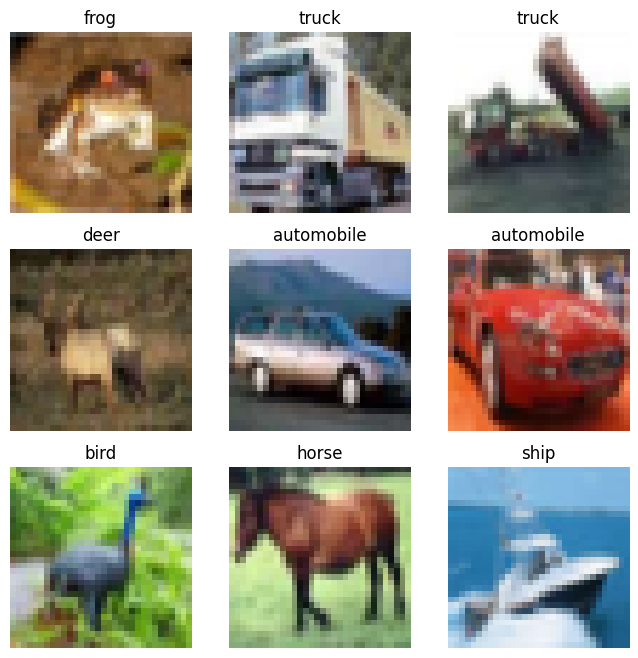

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training CNN Model...
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 44ms/step - accuracy: 0.4509 - loss: 1.5145 - val_accuracy: 0.5536 - val_loss: 1.2622
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.5882 - loss: 1.1668 - val_accuracy: 0.6185 - val_loss: 1.1009
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.6395 - loss: 1.0294 - val_accuracy: 0.6417 - val_loss: 1.0305
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.6714 - loss: 0.9460 - val_accuracy: 0.6614 - val_loss: 0.9803
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.6976 - loss: 0.8791 - val_accuracy: 0.6811 - val_loss: 0.9280

Output 2: Training Accuracy & Validation Accuracy


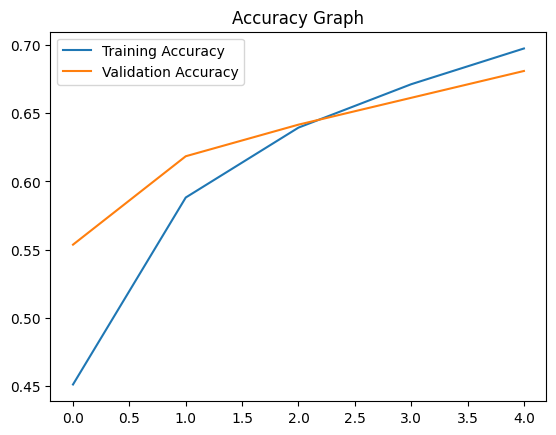


Output 3: Training Loss & Validation Loss


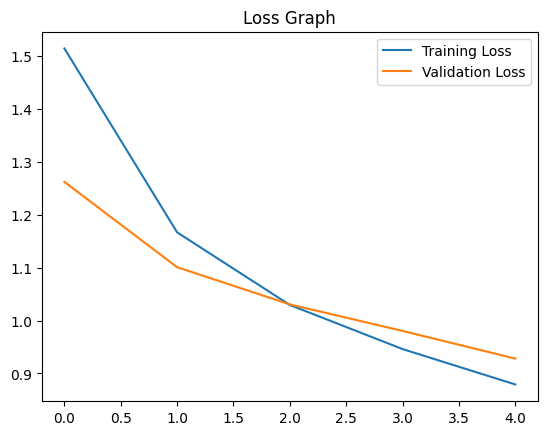


Output 4: Test Accuracy
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6811 - loss: 0.9280
Test Accuracy: 0.6811000108718872

Output 5: Predictions
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


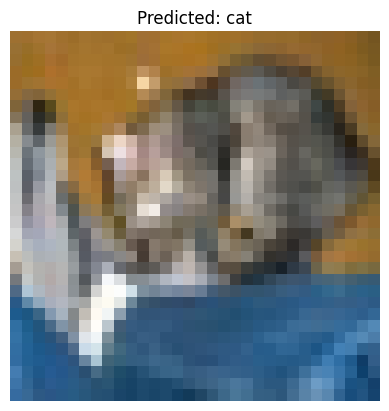

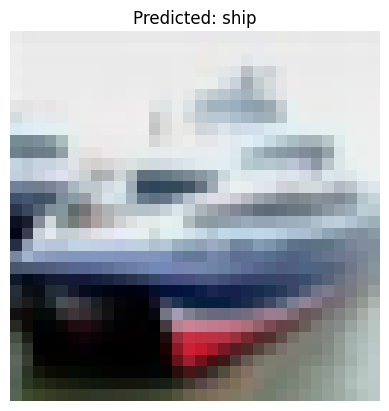

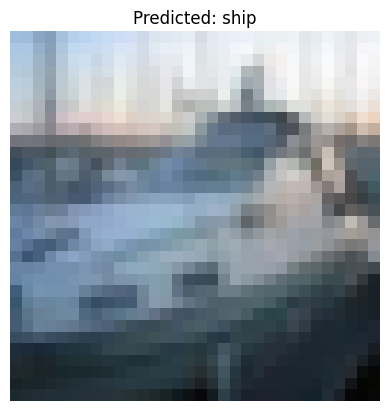

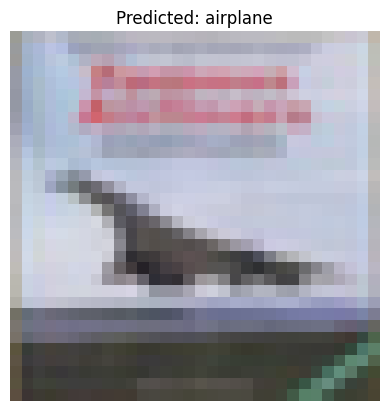

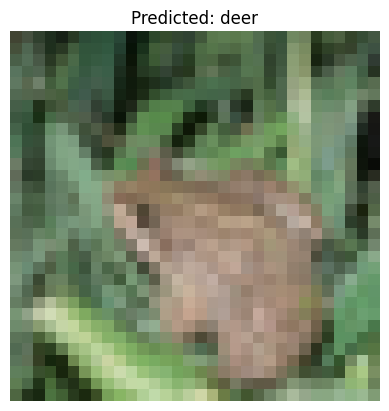

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

print("Loading CIFAR-10 Dataset...")
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

print("\nOutput 1: Sample Training Images")
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()

model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D())
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D())
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("\nTraining CNN Model...")
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

print("\nOutput 2: Training Accuracy & Validation Accuracy")
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

print("\nOutput 3: Training Loss & Validation Loss")
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

print("\nOutput 4: Test Accuracy")
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

print("\nOutput 5: Predictions")
predictions = model.predict(x_test[:5])

for i in range(5):
    plt.imshow(x_test[i])
    plt.title("Predicted: " + class_names[predictions[i].argmax()])
    plt.axis('off')
    plt.show()

In [5]:
pred = prediction[0]
class_id = np.argmax(pred)
confidence = pred[class_id]

print("Predicted:", class_names[class_id])
print("Confidence:", round(confidence * 100, 2), "%")

Predicted: automobile
Confidence: 94.34 %
